In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


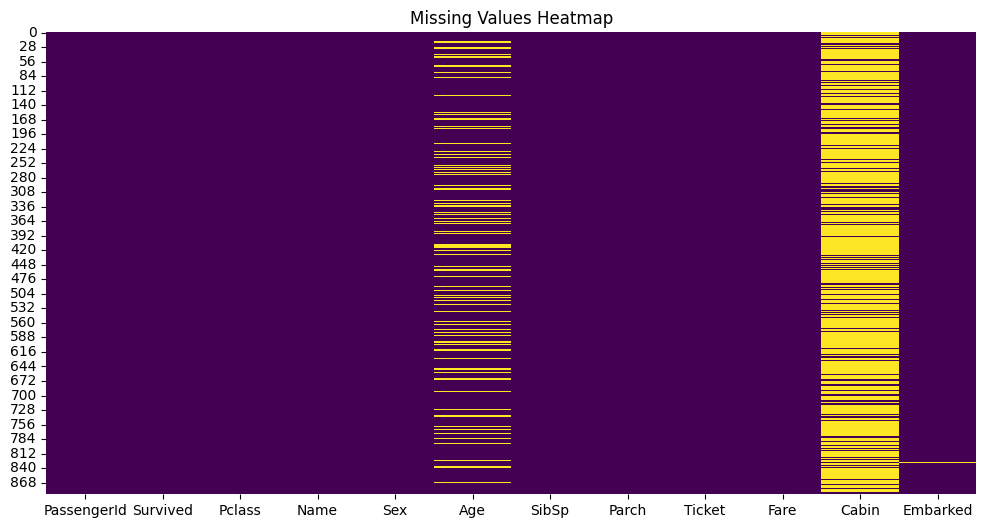

Series([], dtype: int64)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

In [2]:
data = pd.read_csv('train.csv')

# missing values
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100
missing_data = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
print(missing_data[missing_data['Missing Values'] > 0])
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Group-based Age imputation
data['Age'] = (
    data.groupby(['Sex', 'Pclass'])['Age']
        .transform(lambda x: x.fillna(x.mean()))
)

# Fallback
data['Age'] = data['Age'].fillna(data['Age'].mean())


# Cabin feature
if 'Cabin' in data.columns:
    data['Has_Cabin'] = data['Cabin'].notnull().astype(int)
    data.drop(columns=['Cabin'], inplace=True)

# Embarked imputation
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Confirm no missing values
print(data.isnull().sum()[data.isnull().sum() > 0])

data.isnull().sum()

In [3]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = data[features].copy()
y = data['Survived']

# Canza Sex zuwa lamba
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# Cika missing values a Age (idan akwai)
X['Age'] = X['Age'].fillna(X['Age'].median())

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [7]:
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 82.68%
Confusion Matrix:
[[93 12]
 [19 55]]


In [8]:
joblib.dump(model, 'titanic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("An adana model da scaler a cikin folder ɗin nan!")

An adana model da scaler a cikin folder ɗin nan!


In [18]:
# Cell 9: Write the Streamlit app code (as a string)
streamlit_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Set page configuration
st.set_page_config(page_title="Titanic Survival Predictor", page_icon="🚢")

st.title("🚢 Titanic Survival Prediction App")
st.markdown("Welcome! This app will predict whether a passenger would survive the Titanic disaster based on the information you provide.")

# Load model and scaler
@st.cache_resource
def load_model():
    return joblib.load('titanic_model.pkl')

@st.cache_resource
def load_scaler():
    return joblib.load('scaler.pkl')

model = load_model()
scaler = load_scaler()

# Place input widgets in sidebar
st.sidebar.header("🔢 Passenger Information Input")

pclass = st.sidebar.selectbox("Class (Pclass)", [1, 2, 3], 
                               format_func=lambda x: "First Class" if x == 1 else "Second Class" if x == 2 else "Third Class")
sex = st.sidebar.selectbox("Gender (Sex)", ["Female", "Male"])
age = st.sidebar.slider("Age (Years)", 0, 100, 30)
sibsp = st.sidebar.number_input("Siblings/Spouses Aboard (SibSp)", 0, 8, 0)
parch = st.sidebar.number_input("Parents/Children Aboard (Parch)", 0, 6, 0)
fare = st.sidebar.number_input("Ticket Fare (Fare)", 0.0, 600.0, 32.0)

# Display entered information
st.write("### Information You Entered:")
col1, col2 = st.columns(2)
with col1:
    st.write(f"- **Class:** {pclass}")
    st.write(f"- **Gender:** {sex}")
    st.write(f"- **Age:** {age}")
with col2:
    st.write(f"- **Siblings/Spouses:** {sibsp}")
    st.write(f"- **Parents/Children:** {parch}")
    st.write(f"- **Ticket Fare:** £{fare:.2f}")

# Prediction button
if st.button("🔮 Predict Survival", type="primary"):
    # Convert gender to numeric
    sex_numeric = 1 if sex == "Female" else 0
    
    # Prepare data for model
    input_data = np.array([[pclass, sex_numeric, age, sibsp, parch, fare]])
    input_scaled = scaler.transform(input_data)
    
    # Make prediction
    prediction = model.predict(input_scaled)[0]
    prediction_proba = model.predict_proba(input_scaled)[0]
    
    # Display results
    st.markdown("---")
    st.subheader("📊 Prediction Result:")
    
    if prediction == 1:
        st.success(f"### ✅ Passenger WILL SURVIVE!")
        st.metric("Survival Probability", f"{prediction_proba[1]:.1%}")
        
        # Add progress bar to show probability
        st.progress(prediction_proba[1])
        st.caption(f"Death Probability: {prediction_proba[0]:.1%}")
    else:
        st.error(f"### ❌ Passenger WILL NOT SURVIVE!")
        st.metric("Death Probability", f"{prediction_proba[0]:.1%}")
        
        # Add progress bar to show probability
        st.progress(prediction_proba[0])
        st.caption(f"Survival Probability: {prediction_proba[1]:.1%}")
    
    # Add explanation about factors affecting survival
    st.markdown("---")
    st.info("💡 **What influenced this prediction:** " + 
            ("Women are more likely to survive" if sex == "Female" else "Men have lower survival rates") + 
            f", and passengers in class {pclass} " + 
            ("have a good chance" if pclass == 1 else "have a lower chance"))

# Add footer information
st.markdown("---")
st.caption("App built with Streamlit and Logistic Regression model on the Titanic dataset")
st.image('images/confusion_matrix.png', caption='Model Confusion Matrix')
"""

In [21]:
# Cell 10: Export the code to a Python file
with open('titanic_app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print("File 'titanic_app.py' has been created!")
print("You can now run it with: streamlit run titanic_app.py")

File 'titanic_app.py' has been created!
You can now run it with: streamlit run titanic_app.py


In [22]:
# Cell 11: Create and save images from your model
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Confusion Matrix plot
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix - Titanic Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Save the image
plt.savefig('images/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.close()

print("Confusion matrix image saved in the 'images' folder")

Confusion matrix image saved in the 'images' folder
